# Indian Tourism Sentiment Analysis 

# Importing Important Libraries

In [1]:
import pandas as pd                 # For data manipulation
import numpy as np                  # For numerical operations
import matplotlib.pyplot as plt     # For visualization
import seaborn as sns               # For advanced visualization
import re                           # For text cleaning
import string                       # For punctuation removal

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Loading the Dataset

In [2]:
df=pd.read_csv("Review_db.csv")

In [3]:
df

,City,Place,Review,Rating,Name,Date,Raw_Review
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,5,Anonymous,NaN,Aamby valley is a beautiful place with its cle...
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4,Anonymous,NaN,Very well executed obt by Akshay.... Thanx as ...
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,5,Anonymous,NaN,Awesome experience at the ATV\nTracts and obst...
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,4,Anonymous,NaN,we visited the Aamby Valley yesterday for shor...
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,5,Anonymous,NaN,"Not far from Mumbai, this place is one of the ..."
...,...,...,...,...,...,...,...
1482461,Zuluk,Zuluk Wildlife Area,zuluk week march mst virgin unexplored region ...,3,Anonymous,NaN,We had been to zuluk in the last week of march...
1482462,Zuluk,Zuluk Wildlife Area,planned visit eastern sikkim time covered stat...,3,Anonymous,NaN,We planned to visit eastern part of Sikkim thi...
1482463,Zuluk,Zuluk Wildlife Area,excellent watched place east sikkim visited pl...,5,Anonymous,NaN,A excellent & must watched place for east sikk...
1482464,Zuluk,Zuluk Wildlife Area,beautiful areas sikkim falls eastern sikkim an...,4,Anonymous,NaN,One of the most beautiful areas in Sikkim... i...


# Data Understanding

In [5]:
df.head()

,City,Place,Review,Rating,Name,Date,Raw_Review
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,5,Anonymous,NaN,Aamby valley is a beautiful place with its cle...
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4,Anonymous,NaN,Very well executed obt by Akshay.... Thanx as ...
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,5,Anonymous,NaN,Awesome experience at the ATV\nTracts and obst...
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,4,Anonymous,NaN,we visited the Aamby Valley yesterday for shor...
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,5,Anonymous,NaN,"Not far from Mumbai, this place is one of the ..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482466 entries, 0 to 1482465
Data columns (total 7 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   City        1482466 non-null  object 
 1   Place       1482466 non-null  object 
 2   Review      1482466 non-null  object 
 3   Rating      1482466 non-null  int64  
 4   Name        1482466 non-null  object 
 5   Date        0 non-null        float64
 6   Raw_Review  1482466 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 79.2+ MB


In [9]:
df.columns

Index(['City', 'Place', 'Review', 'Rating', 'Name', 'Date', 'Raw_Review'], dtype='object')

In [10]:
df.isnull().sum()

City                0
Place               0
Review              0
Rating              0
Name                0
Date          1482466
Raw_Review          0
dtype: int64

In [11]:
df.shape

(1482466, 7)

# Data Cleaning

#  Remove Missing Reviews or Ratings

In [12]:
# Remove rows with missing review or rating
df = df.dropna(subset=['Review', 'Rating'])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (1482466, 7)


#  Remove Duplicates

In [13]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1468246, 7)


#  Text Cleaning

In [14]:
def clean_text(text):
    text = str(text).lower()                           # Convert to lowercase
    text = re.sub(r'http\S+', '', text)                # Remove URLs
    text = re.sub(r'\d+', '', text)                    # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = text.strip()                                # Remove extra spaces
    return text

df['Clean_Review'] = df['Review'].apply(clean_text)

# Exploratory Data Analysis (EDA)

# Rating Distribution

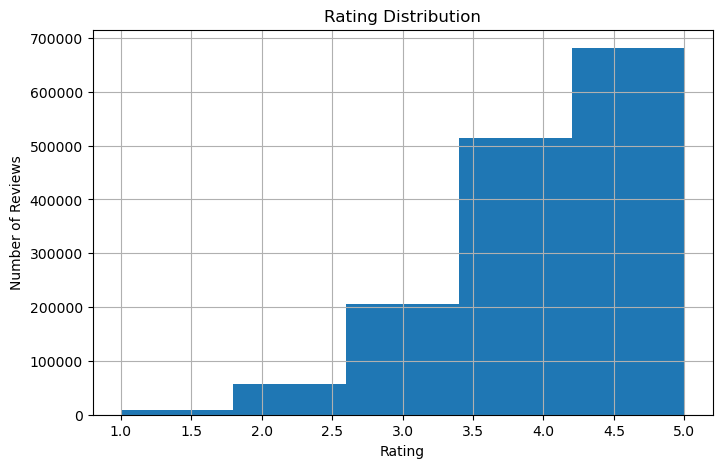

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['Rating'], bins=5) 
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.grid(True)
plt.show()

# Top 10 Cities

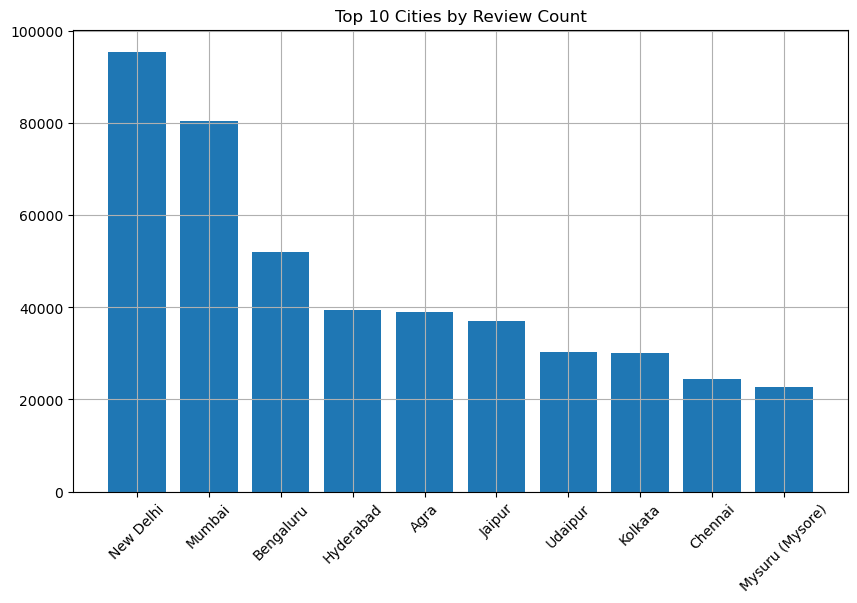

In [17]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_cities.index, top_cities.values)
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Review Count")
plt.grid(True)
plt.show()

# Average Rating per City

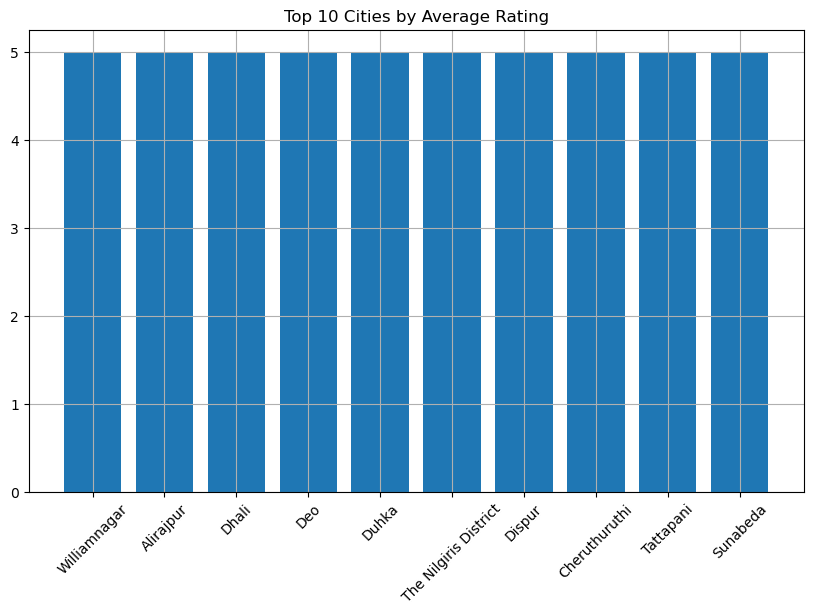

In [19]:
avg_rating = df.groupby('City')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(avg_rating.index, avg_rating.values)
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Average Rating")
plt.grid(True)
plt.show()

# 🟢 Create Sentiment Labels

In [20]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(sentiment_label)

print(df['Sentiment'].value_counts())

Sentiment
Positive    1195770
Neutral      206051
Negative      66425
Name: count, dtype: int64


# Sentiment Distribution Graph

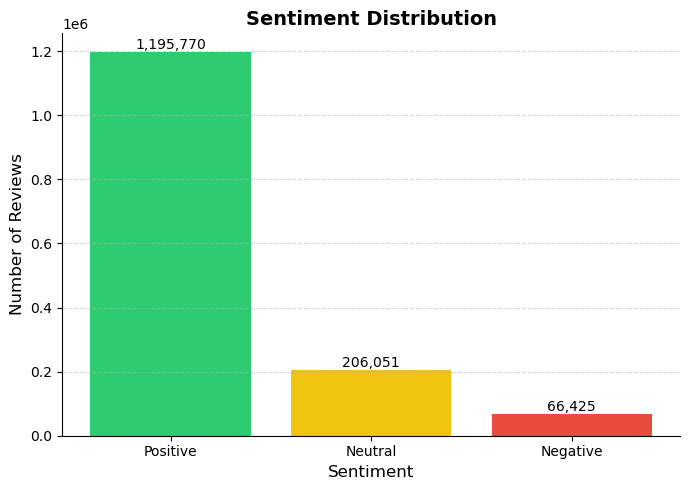

In [22]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Define custom colors (Professional & Soft)
colors = ['#2ecc71', '#f1c40f', '#e74c3c']  
# Green → Positive
# Yellow → Neutral
# Red → Negative

plt.figure(figsize=(7,5))

bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

plt.title("Sentiment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Remove top and right border (clean look)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:,}',
             ha='center',
             va='bottom',
             fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
# Use 300,000 rows for model training to avoid memory crash
df_sample = df.sample(300000, random_state=42)

# 🟢 Convert Text to Numbers (TF-IDF)

In [24]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df_sample['Clean_Review'])
y = df_sample['Sentiment']

# 🟢 Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 🟢 Train Model (Logistic Regression)

In [26]:

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 🟢  Model Evaluation

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9270833333333334

Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.41      0.52      2665
     Neutral       0.76      0.75      0.75      8400
    Positive       0.96      0.99      0.97     48935

    accuracy                           0.93     60000
   macro avg       0.81      0.71      0.75     60000
weighted avg       0.92      0.93      0.92     60000


Confusion Matrix:

[[ 1093  1388   184]
 [  374  6273  1753]
 [   61   615 48259]]


# 🟢 City Wise Sentiment Analysis

In [28]:
city_sentiment = df.groupby(['City', 'Sentiment']).size().unstack()

city_sentiment.head()

Sentiment,Negative,Neutral,Positive
City,,,
Aamby Valley City,NaN,1.0,16.0
Abhaneri,34.0,123.0,708.0
Acharapakkam,1.0,NaN,1.0
Achooranam,1.0,8.0,35.0
Achrol,NaN,NaN,30.0


# 🟢  Save Model

In [29]:
import joblib

joblib.dump(model, "tourism_sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']